<a href="https://colab.research.google.com/github/TanviDhuri18/CSL701-CS13_Machine-Learning-Lab/blob/main/CS07_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Pooja Suresh Bodekar Roll no:CS07 Batch:CS01

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias

### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target/class column
df["target"] = iris.target

# Display the first five rows
print(df.head())

# Display dataset shape
print("Dataset shape:", df.shape)

# Display class names
print("Classes:", iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Dataset shape: (150, 5)
Classes: ['setosa' 'versicolor' 'virginica']


# Task 2: Explore the Dataset

In [ ]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display the last 5 rows
print("\nLast 5 rows of the dataset:")
print(df.tail())

# Display dataset information
print("\nDataset Information:")
print(df.info())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display class distribution
print("\nClass Distribution:")
print(df["target"].value_counts())

# Display class names
print("\nClass Names:")
for i, name in enumerate(iris.target_names):
    print(i, ":", name)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Last 5 rows of the dataset:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4            

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Remove the Id column
df = df.drop(columns=["Id"], errors="ignore")

# Select features
X = df.drop(columns=["target"])

# Select target
y = df["target"]

# Display the selected features
print("Features (X):")
print(X.head())

# Display the target
print("\nTarget (y):")
print(y.head())

# Display shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Shape of X: (150, 4)
Shape of y: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Scaled training data shape: (120, 4)
Scaled testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
from sklearn.svm import SVC

# Create the Linear SVM model
linear_svm = SVC(kernel="linear", random_state=42)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred_linear = linear_svm.predict(X_test_scaled)

# Display predictions
print("Predicted labels:")
print(y_pred_linear)

print("\nActual labels:")
print(y_test.to_numpy())

Predicted labels:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Actual labels:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Linear SVM Accuracy:
1.0000
100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


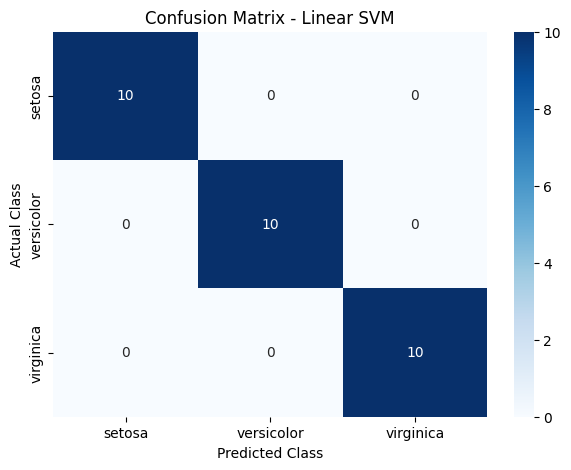


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:")
print(f"{accuracy:.4f}")
print(f"{accuracy * 100:.2f}%")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_linear)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=iris.target_names
    )
)

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

X shape: (150, 2)
y shape: (150,)


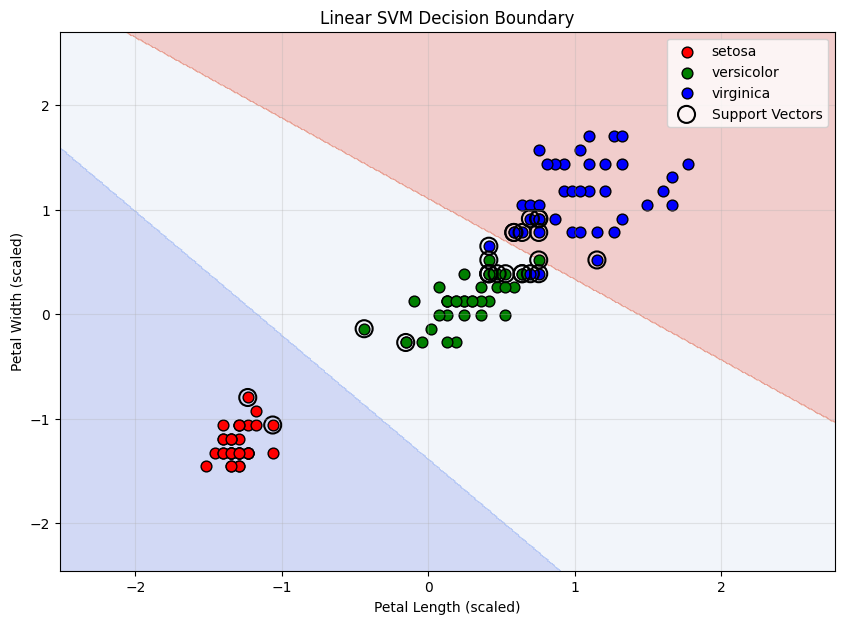

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# --------------------------------------------------
# 1. Load the Iris dataset
# --------------------------------------------------
iris = load_iris()

# Select Petal Length and Petal Width
X = iris.data[:, [2, 3]]
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

# --------------------------------------------------
# 2. Split the data
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 3. Scale the data
# --------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 4. Train Linear SVM
# --------------------------------------------------
linear_svm = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

linear_svm.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 5. Create mesh grid for decision boundary
# --------------------------------------------------
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict class for every point in the mesh
Z = linear_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# --------------------------------------------------
# 6. Plot decision boundary
# --------------------------------------------------
plt.figure(figsize=(10, 7))

# Background showing predicted regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

# Plot training data points
colors = ["red", "green", "blue"]

for i, color in enumerate(colors):
    plt.scatter(
        X_train_scaled[y_train == i, 0],
        X_train_scaled[y_train == i, 1],
        c=color,
        label=iris.target_names[i],
        edgecolors="black",
        s=60
    )

# Plot support vectors
plt.scatter(
    linear_svm.support_vectors_[:, 0],
    linear_svm.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# 1. Create Logistic Regression model
# --------------------------------------------------
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=200
)

# --------------------------------------------------
# 2. Train the model
# --------------------------------------------------
logistic_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 3. Make predictions
# --------------------------------------------------
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

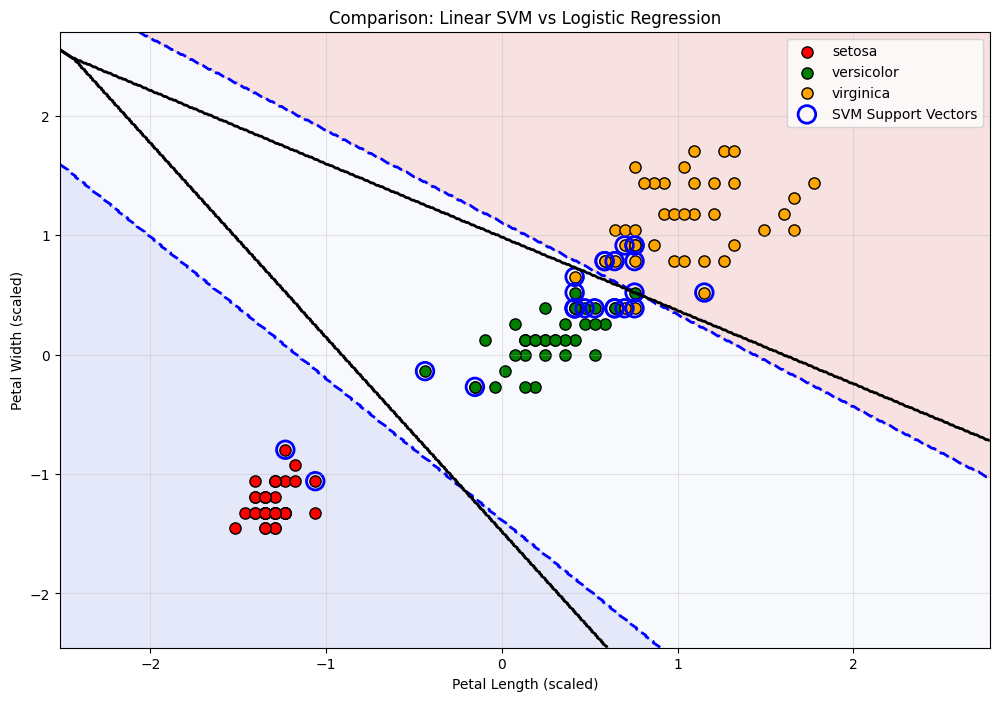

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create a common mesh grid
# --------------------------------------------------
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Points in the mesh
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# Predictions from both classifiers
Z_svm = linear_svm.predict(mesh_points).reshape(xx.shape)
Z_logistic = logistic_model.predict(mesh_points).reshape(xx.shape)

# --------------------------------------------------
# Plot both decision boundaries
# --------------------------------------------------
plt.figure(figsize=(12, 8))

# SVM decision regions
plt.contourf(
    xx,
    yy,
    Z_svm,
    alpha=0.15,
    cmap=plt.cm.coolwarm
)

# SVM decision boundaries
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    colors="blue",
    linewidths=2,
    linestyles="--"
)

# Logistic Regression decision boundaries
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    colors="black",
    linewidths=2,
    linestyles="-"
)

# --------------------------------------------------
# Plot training data
# --------------------------------------------------
colors = ["red", "green", "orange"]

for i, color in enumerate(colors):
    plt.scatter(
        X_train_scaled[y_train == i, 0],
        X_train_scaled[y_train == i, 1],
        c=color,
        label=iris.target_names[i],
        edgecolors="black",
        s=65
    )

# --------------------------------------------------
# Highlight SVM support vectors
# --------------------------------------------------
plt.scatter(
    linear_svm.support_vectors_[:, 0],
    linear_svm.support_vectors_[:, 1],
    s=160,
    facecolors="none",
    edgecolors="blue",
    linewidths=2,
    label="SVM Support Vectors"
)

# --------------------------------------------------
# Labels and title
# --------------------------------------------------
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Comparison: Linear SVM vs Logistic Regression")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

========== ACCURACY ==========
Linear SVM:          1.0000 (100.00%)
Logistic Regression: 0.9333 (93.33%)

========== SVM CONFUSION MATRIX ==========
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

========== LOGISTIC REGRESSION CONFUSION MATRIX ==========
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


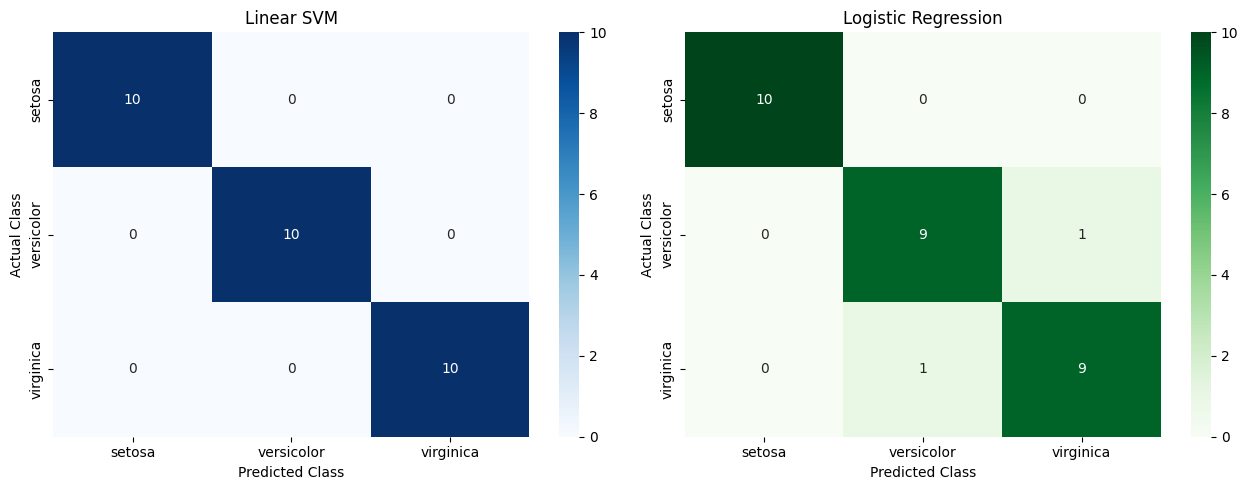


========== LINEAR SVM CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Accuracy
# --------------------------------------------------

svm_accuracy = accuracy_score(y_test, y_pred_linear)
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("========== ACCURACY ==========")
print(f"Linear SVM:          {svm_accuracy:.4f} ({svm_accuracy * 100:.2f}%)")
print(f"Logistic Regression: {logistic_accuracy:.4f} ({logistic_accuracy * 100:.2f}%)")


# --------------------------------------------------
# 2. Confusion Matrices
# --------------------------------------------------

svm_cm = confusion_matrix(y_test, y_pred_linear)
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print("\n========== SVM CONFUSION MATRIX ==========")
print(svm_cm)

print("\n========== LOGISTIC REGRESSION CONFUSION MATRIX ==========")
print(logistic_cm)


# --------------------------------------------------
# Visualize both confusion matrices
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[0]
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")


sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[1]
)

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Classification Reports
# --------------------------------------------------

print("\n========== LINEAR SVM CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=iris.target_names
    )
)


print("\n========== LOGISTIC REGRESSION CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.